# Iterations Summary Analysis

This notebook analyzes the rows written by `julia/scripts/main_iterator.jl` in `experiments/iterations_summary.csv`.
It groups runs by batch prefix, lists the n/beta combinations present in each batch, and flags batches that are complete in the sense that every expected n_qubits x beta pair appears at least once.

In [1]:
from pathlib import Path
import math
import numpy as np
import re
import tomllib
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
CANDIDATE_ROOTS = [NOTEBOOK_DIR, NOTEBOOK_DIR.parent]

PLOTS_LAYOUT = [
    ["amplitude_damping", "phase_damping"],
    ["phase_damping", "amplitude_damping"],
    ["bitflip", "amplitude_damping"],
    ["amplitude_damping", "bitflip"],
    ["amplitude_damping", "general"],
    ["general", "amplitude_damping"],
    ["general", "general"],
]

PROJECT_ROOT = NOTEBOOK_DIR.parent
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments" / "00_test2"
SUMMARY_CSV = EXPERIMENTS_DIR / "iterations_summary.csv"

## One Qubit Simulations

In [2]:
def batch_prefix(name: str) -> str:
    return re.sub(r"n\d+_b\d+(?:_.*)?$", "", name)


def normalize_bool(value) -> bool:
    if isinstance(value, bool):
        return value
    if value is None:
        return False
    if isinstance(value, float) and math.isnan(value):
        return False
    if isinstance(value, (int, float)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def noise_name_from_option(option):
    if isinstance(option, (list, tuple)) and len(option) >= 2:
        return option[1]
    return None


def other_noise_from_options(noise_options, real_noise: str | None) -> str | None:
    noise_names = [noise_name_from_option(option) for option in noise_options]
    noise_names = [noise_name for noise_name in noise_names if noise_name]
    for noise_name in noise_names:
        if noise_name != real_noise:
            return noise_name
    return noise_names[0] if noise_names else None


def infer_other_noise(row: pd.Series) -> str | None:
    real_noise = row.get("real_noise")
    for column in ["noise_1_name", "noise_2_name"]:
        noise_name = row.get(column)
        if pd.notna(noise_name) and noise_name != real_noise:
            return noise_name
    return row.get("noise_1_name") if pd.notna(row.get("noise_1_name")) else None


def read_config_metadata(experiments_dir: Path, experiment_name: str) -> dict:
    config_path = experiments_dir / experiment_name / "config.toml"
    metadata = {
        "config_path": config_path,
        "config_exists": config_path.exists(),
        "config_correlated_noise": None,
        "config_real_noise": None,
        "config_other_noise": None,
        "config_noise_1_name": None,
        "config_noise_2_name": None,
    }
    if not metadata["config_exists"]:
        return metadata

    with config_path.open("rb") as handle:
        config = tomllib.load(handle)

    noise_options = config.get("noise_options", [])
    real_noise = config.get("real_noise")
    metadata.update(
        {
            "config_correlated_noise": normalize_bool(config.get("correlated_noise")),
            "config_real_noise": real_noise,
            "config_other_noise": other_noise_from_options(noise_options, real_noise),
            "config_noise_1_name": noise_name_from_option(noise_options[0]) if len(noise_options) > 0 else None,
            "config_noise_2_name": noise_name_from_option(noise_options[1]) if len(noise_options) > 1 else None,
        }
    )
    return metadata

def get_noise_name(name: str, correlated: bool, n_qubits=1) -> str:
    str_name = ""
    if n_qubits > 1:
      if correlated:
          str_name += "Correlated "
      else:
          str_name += "Uncorrelated "
    str_name += (" ".join(name.split("_"))).title()
    str_name += " Noise"
    return str_name

In [3]:

def config_metadata_discrepancies(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    checks = [
        ("correlated_noise", "csv_correlated_noise", "config_correlated_noise"),
        ("real_noise", "csv_real_noise", "config_real_noise"),
        ("noise_1_name", "csv_noise_1_name", "config_noise_1_name"),
        ("noise_2_name", "csv_noise_2_name", "config_noise_2_name"),
    ]
    for _, row in frame.loc[frame["config_exists"]].iterrows():
        for field, csv_col, config_col in checks:
            csv_value = row.get(csv_col)
            config_value = row.get(config_col)
            if pd.isna(config_value) or csv_value == config_value:
                continue
            rows.append(
                {
                    "name": row["name"],
                    "field": field,
                    "csv_value": csv_value,
                    "config_value": config_value,
                    "config_path": row["config_path"],
                }
            )
    return pd.DataFrame(rows)


def load_summary_frame(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    frame["batch"] = frame["name"].map(batch_prefix)
    frame["n_qubits"] = frame["n_qubits"].astype(int)
    frame["beta"] = frame["beta"].astype(float)
    frame["avg_fidelity"] = frame["avg_fidelity"].astype(float)
    frame["infidelity"] = 1.0 - frame["avg_fidelity"]

    frame["csv_correlated_noise"] = frame["correlated_noise"].map(normalize_bool)
    frame["csv_real_noise"] = frame["real_noise"]
    frame["csv_noise_1_name"] = frame["noise_1_name"]
    frame["csv_noise_2_name"] = frame["noise_2_name"]

    config_frame = pd.DataFrame(
        [read_config_metadata(path.parent, experiment_name) for experiment_name in frame["name"]]
    )
    frame = pd.concat([frame.reset_index(drop=True), config_frame], axis=1)

    config_mask = frame["config_exists"]
    frame["correlated_noise"] = frame["csv_correlated_noise"]
    frame.loc[config_mask, "correlated_noise"] = frame.loc[config_mask, "config_correlated_noise"]
    frame.loc[config_mask, "real_noise"] = frame.loc[config_mask, "config_real_noise"]
    frame.loc[config_mask, "noise_1_name"] = frame.loc[config_mask, "config_noise_1_name"]
    frame.loc[config_mask, "noise_2_name"] = frame.loc[config_mask, "config_noise_2_name"]
    frame["other_noise"] = frame["config_other_noise"]
    frame.loc[~config_mask, "other_noise"] = frame.loc[~config_mask].apply(infer_other_noise, axis=1)
    return frame


def summarize_batches(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for batch, group in frame.groupby("batch", sort=True):
        n_values = sorted(group["n_qubits"].unique().tolist())
        beta_values = sorted(group["beta"].unique().tolist())
        combo_frame = group[["n_qubits", "beta"]].drop_duplicates()
        observed = set(map(tuple, combo_frame.to_numpy()))
        expected = {(n, beta) for n in n_values for beta in beta_values}
        missing = sorted(expected - observed)

        rows.append(
            {
                "batch": batch,
                "rows": len(group),
                "unique_combos": len(observed),
                "expected_combos": len(expected),
                "complete": not missing,
                "n_qubits": n_values,
                "betas": beta_values,
                "missing_combos": missing,
            }
        )

    return pd.DataFrame(rows).sort_values("batch").reset_index(drop=True)





In [4]:
summary_df = load_summary_frame(SUMMARY_CSV)
summary_df = summary_df.sort_values(["batch", "n_qubits", "beta", "name"]).reset_index(drop=True)
metadata_issues_df = config_metadata_discrepancies(summary_df)

if metadata_issues_df.empty:
    print("Config metadata check: no CSV/config mismatches found.")
else:
    print(f"Config metadata check: found {len(metadata_issues_df)} CSV/config mismatches; using config values downstream.")
    # display(metadata_issues_df)

# summary_df


Config metadata check: no CSV/config mismatches found.


In [5]:
# Remove old simulations
summary_df = summary_df[~summary_df['name'].str.contains("20261106")]

In [6]:

batch_summary_df = summarize_batches(summary_df)
complete_batches_df = batch_summary_df.loc[batch_summary_df["complete"]].copy()
incomplete_batches_df = batch_summary_df.loc[~batch_summary_df["complete"]].copy()

print("Complete batches:")
# display(complete_batches_df[["batch", "rows", "unique_combos", "n_qubits", "betas"]])

print("\nIncomplete batches and missing combinations:")
# display(incomplete_batches_df[["batch", "unique_combos", "expected_combos", "missing_combos"]])

print("\nFull batch summary:")
# display(batch_summary_df)


Complete batches:

Incomplete batches and missing combinations:

Full batch summary:


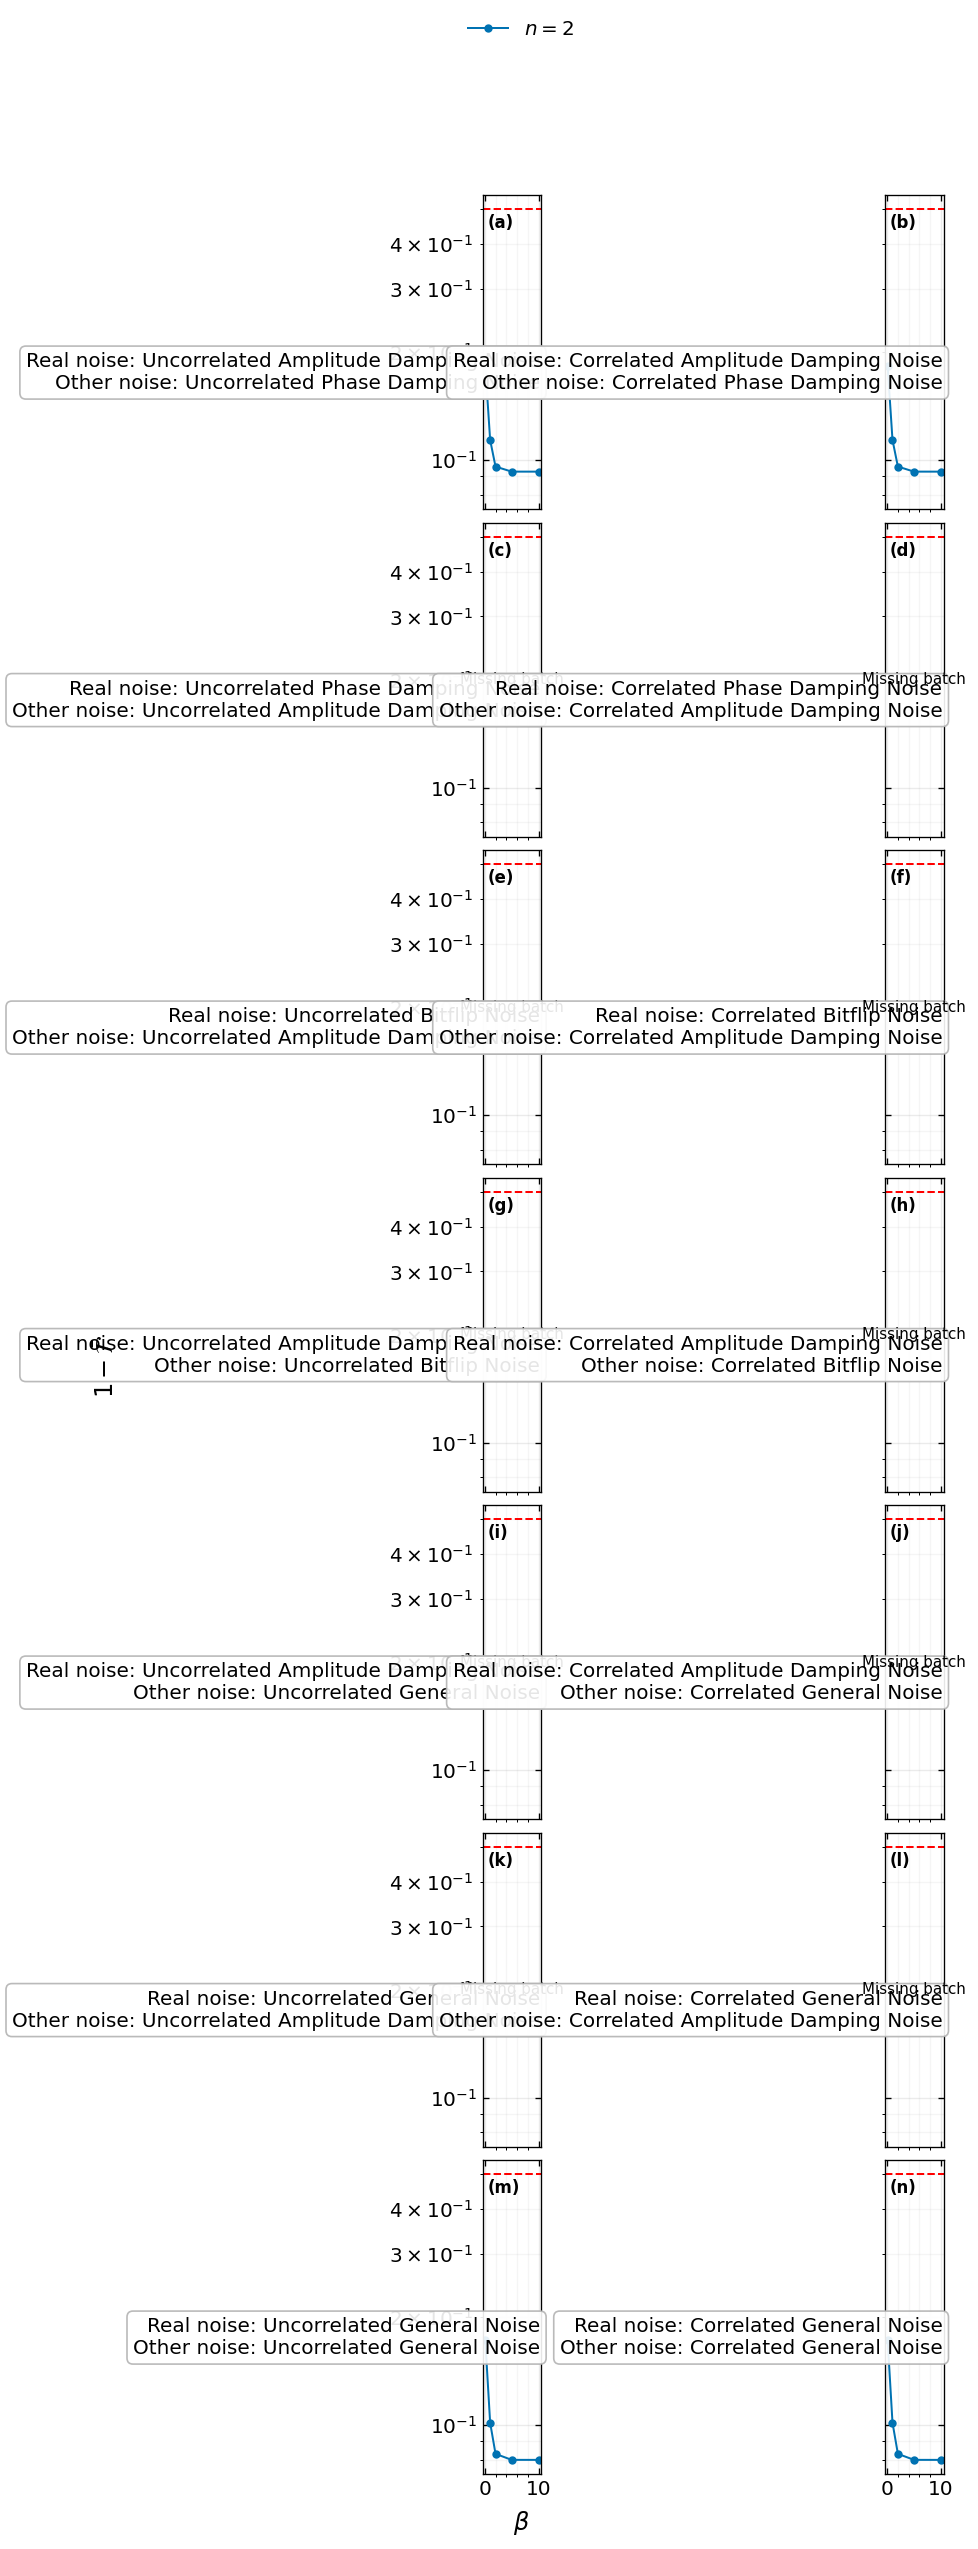

/tmp/ipykernel_4040882/1922771797.py:251: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig_comparison.savefig(EXPERIMENTS_DIR / "comparison_grid_all.png", dpi=300)
/tmp/ipykernel_4040882/1922771797.py:252: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig_comparison.savefig(EXPERIMENTS_DIR / "comparison_grid_all.pdf", dpi=300)


In [ ]:
def add_layout_columns(frame: pd.DataFrame, *, batch_col: str) -> pd.DataFrame:
    prepared = frame.copy()
    if "other_noise" not in prepared.columns:
        prepared["other_noise"] = prepared.apply(infer_other_noise, axis=1)
    else:
        missing_other_noise = prepared["other_noise"].isna()
        prepared.loc[missing_other_noise, "other_noise"] = prepared.loc[missing_other_noise].apply(
            infer_other_noise, axis=1
        )

    prepared["layout_noise_1"] = prepared["real_noise"]
    prepared["layout_noise_2"] = prepared["other_noise"]
    prepared["layout_correlation"] = prepared["correlated_noise"].map(normalize_bool)
    return prepared


def plot_batch_grid(
    frame: pd.DataFrame,
    *,
    layout: list[list[str]] | None = None,
    batch_col: str = "batch",
    series_col: str = "n_qubits",
    series_label: str = r"n",
    x_col: str = "beta",
    x_label: str = r"$\beta$",
    fidelity_col: str = "avg_fidelity",
    plot_infidelity: bool = True,
    figsize: tuple[float, float] | None = None,
    figsize_per_plot: tuple[float, float] = (3.6, 2.8),
    log_scale: bool | None = None,
    ylim: tuple[float, float] | None = None,
    xlim: tuple[float, float] | None = None,
    title: str | None = None,
    savepath: str | None = None,
    dpi: int = 600,
    show: bool = True,
    panel_labels: bool = True,
    info_box: bool = True,
    latex: bool = False,
):

    prepared = add_layout_columns(frame, batch_col=batch_col)
    selected_layout = layout or PLOTS_LAYOUT

    n_rows = len(selected_layout)
    n_cols = 2

    if log_scale is None:
        log_scale = plot_infidelity

    if figsize is None:
      figsize = (
          figsize_per_plot[0] * n_cols,
          figsize_per_plot[1] * n_rows,
      )

    colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]
    markers = ["o", "^", "v", "s", "D", "P", "X"]

    ylabel = r"$1-\bar{\mathcal{F}}$" if plot_infidelity else r"$\bar{\mathcal{F}}$"

    with plt.rc_context({
        "font.size": 12,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 120,
        "savefig.dpi": dpi,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "lines.markersize": 4,
        "text.usetex": latex,
        "font.family": "serif" if latex else "sans-serif",
    }):

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=figsize,
            squeeze=False,
            sharex=True,
            sharey=True,
            constrained_layout=True,
        )

        legend_handles = {}

        for row_index, (noise_1, noise_2) in enumerate(selected_layout):
            for col_index, correlated in enumerate([False, True]):
                ax = axes[row_index, col_index]

                slot_frame = prepared.loc[
                    (prepared["layout_noise_1"] == noise_1)
                    & (prepared["layout_noise_2"] == noise_2)
                    & (prepared["layout_correlation"] == correlated),
                    [batch_col, series_col, x_col, fidelity_col],
                ].copy()

                real_noise = get_noise_name(noise_1, correlated, n_qubits=2)
                other_noise = get_noise_name(noise_2, correlated, n_qubits=2)

                info_text = (
                    f"Real noise: {real_noise}\n"
                    f"Other noise: {other_noise}"
                )

                panel_index = row_index * n_cols + col_index

                if panel_labels:
                    ax.text(
                        0.08,
                        0.94,
                        f"({chr(97 + panel_index)})",
                        transform=ax.transAxes,
                        va="top",
                        ha="left",
                        fontsize=10,
                        fontweight="bold",
                    )

                if info_box:
                    ax.text(
                        0.98,
                        0.5,
                        info_text,
                        transform=ax.transAxes,
                        va="top",
                        ha="right",
                        fontsize=12,
                        bbox=dict(
                            boxstyle="round,pad=0.3",
                            facecolor="white",
                            edgecolor="0.7",
                            alpha=0.9,
                        ),
                    )

                ax.grid(True, which="major", alpha=0.25)
                ax.grid(True, which="minor", alpha=0.12)

                ax.tick_params(direction="in", top=True, right=True)
                ax.minorticks_on()

                ax.axhline(0.5, ls="--", c="red")

                if slot_frame.empty:
                    ax.text(
                        0.5,
                        0.5,
                        "Missing batch",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                        fontsize=9,
                    )
                    continue

                if plot_infidelity:
                    slot_frame["plot_metric"] = 1.0 - slot_frame[fidelity_col]
                else:
                    slot_frame["plot_metric"] = slot_frame[fidelity_col]

                plot_frame = (
                    slot_frame
                    .groupby([series_col, x_col], as_index=False, sort=True)["plot_metric"]
                    .mean()
                    .sort_values([series_col, x_col])
                )

                n_values = sorted(plot_frame[series_col].unique().tolist())

                for i, n_value in enumerate(n_values):
                    subset = plot_frame.loc[
                        plot_frame[series_col] == n_value
                    ].sort_values(x_col)

                    color = colors[i % len(colors)]
                    marker = markers[i % len(markers)]
                    label = rf"${series_label}={n_value}$"

                    ax.plot(
                        subset[x_col],
                        subset["plot_metric"],
                        marker=marker,
                        color=color,
                        linestyle="-",
                        label=label,
                    )

                    if label not in legend_handles:
                        legend_handles[label] = Line2D(
                            [0],
                            [0],
                            color=color,
                            marker=marker,
                            linestyle="-",
                            linewidth=1.2,
                            markersize=4,
                            label=label,
                        )

                if not plot_infidelity:
                    ax.axhline(
                        1.0,
                        color="0.4",
                        linewidth=0.8,
                        linestyle=":",
                    )

                if log_scale:
                    ax.set_yscale("log")

                if ylim is not None:
                    ax.set_ylim(*ylim)

                if xlim is not None:
                    ax.set_xlim(*xlim)

        fig.supxlabel(x_label)
        fig.supylabel(ylabel)

        if title is not None:
          fig.suptitle(
              title,
              x=0.98, y=1.02,               # right side, same vertical level
              ha="right", va="center",
              fontsize=16
          )

        if legend_handles:
            fig.legend(
                handles=list(legend_handles.values()),
                loc="upper center",
                ncol=len(legend_handles),
                frameon=False,
                bbox_to_anchor=(0.5, 1.08),
            )

        if savepath is not None:
            fig.savefig(savepath, bbox_inches="tight")

        if show:
            plt.show()

        return fig, axes


fig_comparison, axes = plot_batch_grid(
    summary_df,
    layout=PLOTS_LAYOUT,
    log_scale=True,
)

fig_comparison.savefig(EXPERIMENTS_DIR / "comparison_grid_all.png", dpi=300)
fig_comparison.savefig(EXPERIMENTS_DIR / "comparison_grid_all.pdf", dpi=300)



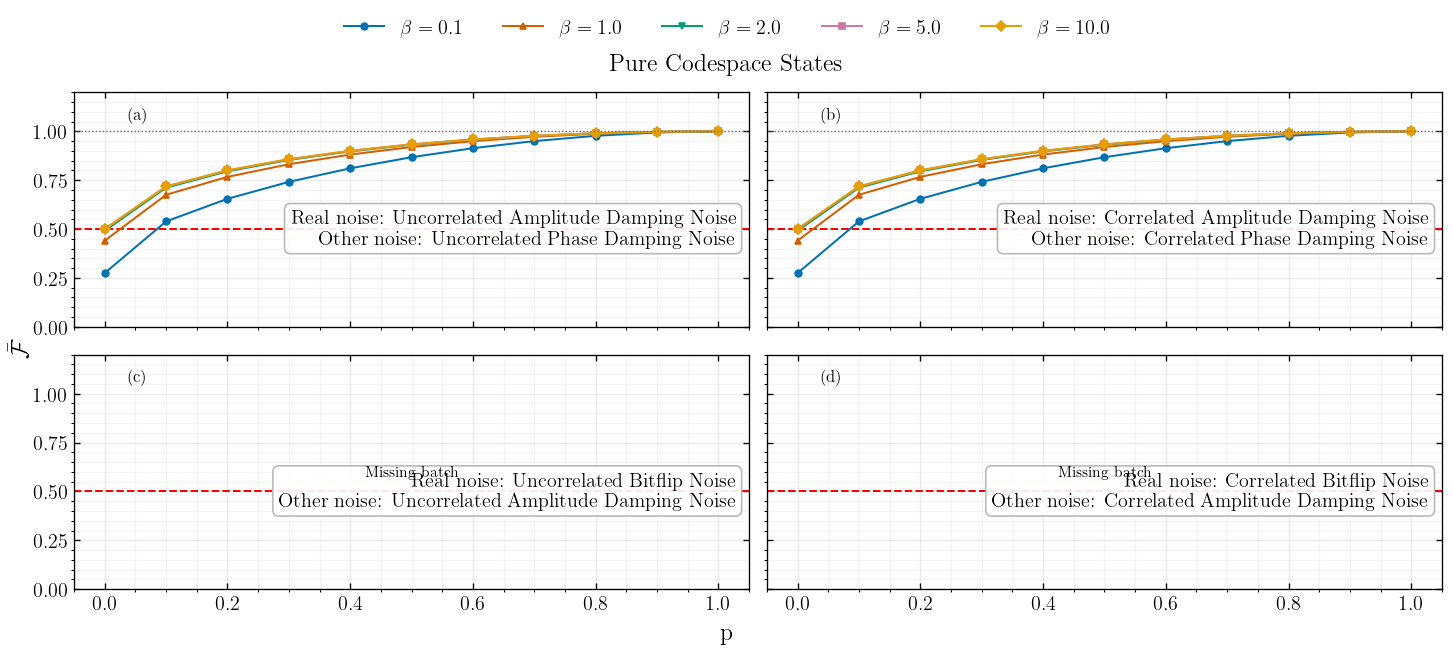

In [10]:
FOUR_PANEL_LAYOUT = [
    ["amplitude_damping", "phase_damping"],
    ["bitflip", "amplitude_damping"],
]

data_to_plot = summary_df[~summary_df["name"].str.contains("mxd")]

fig_comparison, axes = plot_batch_grid(
    data_to_plot,
    series_col="beta",
    series_label=r"\beta",
    x_col="sigma_mixture",
    x_label=r"p",
    layout=FOUR_PANEL_LAYOUT,
    plot_infidelity=False,
    log_scale=False,
    ylim=(0.0, 1.2),
    figsize=(12, 5),
    latex=True,
    title="Pure Codespace States",
    savepath=EXPERIMENTS_DIR / "comparison_grid_4panel.pdf",
    dpi=300,
)

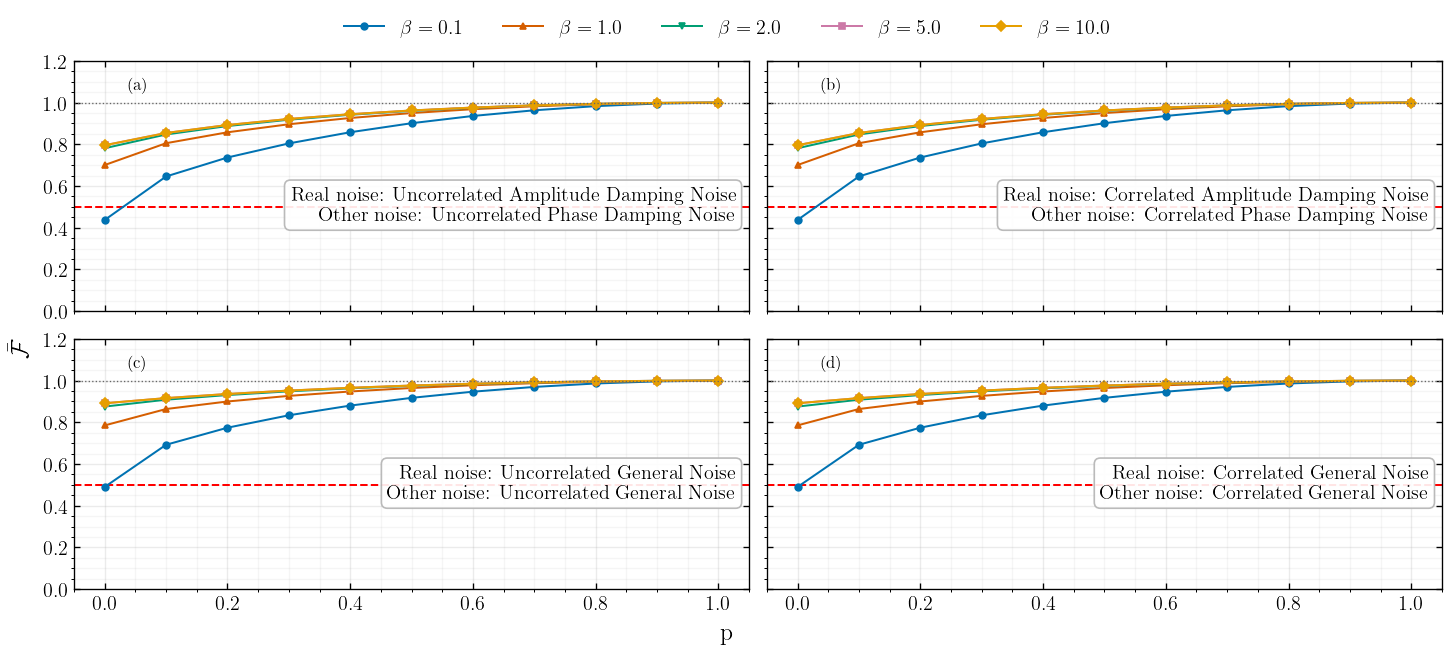

In [136]:
data_to_plot = summary_df[summary_df["name"].str.contains("mxd")]

fig_comparison, axes = plot_batch_grid(
    data_to_plot,
    series_col="beta",
    series_label=r"\beta",
    x_col="sigma_mixture",
    x_label=r"p",
    layout=FOUR_PANEL_LAYOUT,
    plot_infidelity=False,
    log_scale=False,
    ylim=(0.0, 1.2),
    figsize=(12, 5),
    latex=True,
    savepath=EXPERIMENTS_DIR / "comparison_grid_4panel_mixed.pdf",
    dpi=300,
)

In [112]:
data_to_plot.avg_fidelity

110    0.437484
111    0.645999
112    0.736909
113    0.804422
114    0.858011
         ...   
325    0.985175
326    0.991739
327    0.996352
328    0.999092
329    1.000000
Name: avg_fidelity, Length: 220, dtype: float64

In [113]:
summary_df[summary_df["sigma_mixture"] == 0.5][["sigma_mixture","beta", "avg_fidelity"]]

,sigma_mixture,beta,avg_fidelity
5,0.5,0.1,0.867390
16,0.5,10.0,0.933013
27,0.5,1.0,0.919452
38,0.5,2.0,0.931092
49,0.5,5.0,0.933008
60,0.5,0.1,0.867390
71,0.5,10.0,0.933013
82,0.5,1.0,0.919452
93,0.5,2.0,0.931092
104,0.5,5.0,0.933008


In [114]:
prepared = add_layout_columns(summary_df, batch_col="batch")
noise_1 = "general"
noise_2 = "general"
correlated = True
plot_frame = prepared.loc[
                (prepared["layout_noise_1"] == noise_1)
                & (prepared["layout_noise_2"] == noise_2)
                & (prepared["layout_correlation"] == correlated),
                ["name", "batch", "n_qubits", "beta", "infidelity"],
            ]

n_values = sorted(plot_frame["n_qubits"].unique().tolist())
batches = sorted(plot_frame["batch"].unique().tolist())

fig, axs = plt.subplots(1, len(batches), figsize=(8.5, 4.5), sharey=True)

for j, batch in enumerate(batches):
  batch_data = plot_frame.loc[plot_frame["batch"] == batch]
  batch_name = batch_data["batch"].iloc[0]
  for i, n_value in enumerate(n_values):
      subset = batch_data.loc[batch_data["n_qubits"] == n_value].sort_values("beta")
      axs[j].plot(
          subset["beta"],
          subset["infidelity"],
          linewidth=2,
          label=f"n = {n_value}",
      )
  axs[j].set_yscale("log")
  axs[j].set_title(batch_name)


## Check the General Noise Kraus Operators

In [115]:
df = summary_df[summary_df["name"].str.contains("rand")]
df

,name,n_qubits,beta,dt,n_timesteps,n_states,starting_state,recovery_type,collision_unitary,ancilla_state,...,csv_noise_1_name,csv_noise_2_name,config_path,config_exists,config_correlated_noise,config_real_noise,config_other_noise,config_noise_1_name,config_noise_2_name,other_noise
220,test_mxd_rand_rand_b01_sigma_mixture00,2,0.1,0.031416,5,10,thermal,codespace_mxd,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
221,test_mxd_rand_rand_b01_sigma_mixture01,2,0.1,0.031416,5,10,thermal,codespace_mxd,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
222,test_mxd_rand_rand_b01_sigma_mixture02,2,0.1,0.031416,5,10,thermal,codespace_mxd,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
223,test_mxd_rand_rand_b01_sigma_mixture03,2,0.1,0.031416,5,10,thermal,codespace_mxd,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
224,test_mxd_rand_rand_b01_sigma_mixture04,2,0.1,0.031416,5,10,thermal,codespace_mxd,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,test_rand_rand_corr_b50_sigma_mixture06,2,5.0,0.031416,5,10,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,general,general,general,general,general
436,test_rand_rand_corr_b50_sigma_mixture07,2,5.0,0.031416,5,10,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,general,general,general,general,general
437,test_rand_rand_corr_b50_sigma_mixture08,2,5.0,0.031416,5,10,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,general,general,general,general,general
438,test_rand_rand_corr_b50_sigma_mixture09,2,5.0,0.031416,5,10,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,general,general,general,general,general


In [116]:
for row in df.itertuples():
    experiment_dir = EXPERIMENTS_DIR / row.name
    config = read_config_metadata(EXPERIMENTS_DIR, row.name)
    if config["config_real_noise"] != "general" and config["config_other_noise"] != "general":
        print(f"Experiment {row.name} has unexpected noise configuration; skipping.")
        continue
    
